# Regresión sobre California Housing: Lineal, Polinómica y k-NN

**Objetivo:** entrenar y comparar tres modelos de regresión sobre el *California Housing dataset* para predecir el valor mediano de la vivienda (`MedHouseVal`, en unidades de 100.000 USD).

| Elemento | Configuración |
|---|---|
| Modelos | Regresión lineal (`LinearRegression`), regresión polinómica (`PolynomialFeatures` + `LinearRegression`), k-NN (`KNeighborsRegressor`) |
| Partición | definida por el parámetro global `TEST_SIZE` (por defecto 60 % train / 40 % test) |
| Validación | k-fold cross-validation (`KFold`, k = `N_SPLITS`) sobre el conjunto de entrenamiento |
| Salidas | curva de la "función" ajustada (line plot), tablas y gráficos de métricas (RMSE, MAE, R²) |


## 1. Importaciones y parámetros globales

In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import (
    root_mean_squared_error,
    mean_absolute_error,
    r2_score,
)

# ----------------------------- Parámetros globales -----------------------------
RANDOM_STATE = 42     # semilla reproducible
TEST_SIZE = 0.20      # fracción de datos reservada para prueba (0.40 -> 60/40)
N_SPLITS = 5          # folds para la validación cruzada
POLY_DEGREE = 2       # grado de la regresión polinómica
N_NEIGHBORS = 10      # vecinos para k-NN
VIZ_FEATURE = "MedInc"  # característica usada para el line plot
# ----------------------------------------------------------------------------

np.random.seed(RANDOM_STATE)
plt.rcParams["figure.dpi"] = 110
print(f"Partición: {1 - TEST_SIZE:.0%} entrenamiento / {TEST_SIZE:.0%} prueba  |  CV: {N_SPLITS} folds")

Partición: 80% entrenamiento / 20% prueba  |  CV: 5 folds


## 2. Carga y exploración rápida de los datos

In [106]:
housing = fetch_california_housing(as_frame=True)
X = housing.data                 # 8 características numéricas
y = housing.target               # MedHouseVal (en 100.000 USD)
feature_names = list(X.columns)

print(f"Muestras: {X.shape[0]}  |  Características: {X.shape[1]}")
print(f"Objetivo: {housing.target_names[0]}  (rango {y.min():.2f} - {y.max():.2f})")
display(X.describe().T[["mean", "std", "min", "max"]].round(2))
X.head()

Muestras: 20640  |  Características: 8
Objetivo: MedHouseVal  (rango 0.15 - 5.00)


,mean,std,min,max
MedInc,3.87,1.90,0.50,15.00
HouseAge,28.64,12.59,1.00,52.00
AveRooms,5.43,2.47,0.85,141.91
AveBedrms,1.10,0.47,0.33,34.07
Population,1425.48,1132.46,3.00,35682.00
AveOccup,3.07,10.39,0.69,1243.33
Latitude,35.63,2.14,32.54,41.95
Longitude,-119.57,2.00,-124.35,-114.31


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


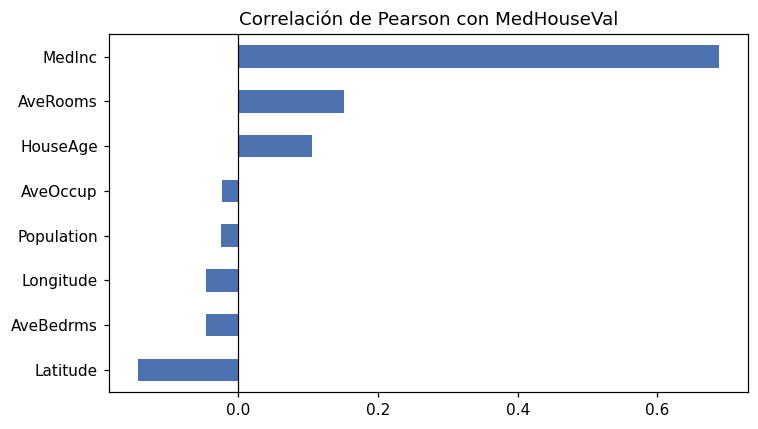

'MedInc' se usará para el line plot (correlación = 0.688).


In [107]:
# Correlación de cada característica con el objetivo
corr = X.assign(MedHouseVal=y).corr()["MedHouseVal"].drop("MedHouseVal").sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
corr.plot.barh(ax=ax, color="#4C72B0")
ax.set_title("Correlación de Pearson con MedHouseVal")
ax.axvline(0, color="k", lw=0.8)
plt.tight_layout()
plt.show()

print(f"'{VIZ_FEATURE}' se usará para el line plot (correlación = {corr[VIZ_FEATURE]:.3f}).")

## 3. Partición train / test (según `TEST_SIZE`)

In [108]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

print(f"Entrenamiento: {X_train.shape[0]:>6} muestras ({X_train.shape[0] / len(X):.0%})")
print(f"Prueba:        {X_test.shape[0]:>6} muestras ({X_test.shape[0] / len(X):.0%})")

Entrenamiento:  16512 muestras (80%)
Prueba:          4128 muestras (20%)


## 4. Definición de los modelos

Cada modelo se envuelve en un `Pipeline` con `StandardScaler`. El escalado es indiferente para la regresión lineal pura y **crítico** para k-NN (distancias).

Para la regresión polinómica el `StandardScaler` va **después** de `PolynomialFeatures`: si se escala antes, elevar a la 4ª potencia columnas ya estandarizadas (con outliers como `AveOccup`) dispara el número de condición del diseño (~2·10⁹ en grado 4) y el solver de mínimos cuadrados deja de encontrar el óptimo. Escalando las 494 columnas expandidas el ajuste vuelve a ser numéricamente estable y monótono en el grado.

In [109]:
models = {
    "Lineal": Pipeline([
        ("scaler", StandardScaler()),
        ("reg", LinearRegression()),
    ]),
    f"Polinómica (grado {POLY_DEGREE})": Pipeline([
        ("poly", PolynomialFeatures(degree=POLY_DEGREE, include_bias=False)),
        ("scaler", StandardScaler()),
        ("reg", LinearRegression()),
    ]),
    f"k-NN (k={N_NEIGHBORS})": Pipeline([
        ("scaler", StandardScaler()),
        ("reg", KNeighborsRegressor(n_neighbors=N_NEIGHBORS)),
    ]),
}
models

{'Lineal': Pipeline(steps=[('scaler', StandardScaler()), ('reg', LinearRegression())]),
 'Polinómica (grado 2)': Pipeline(steps=[('poly', PolynomialFeatures(include_bias=False)),
                 ('scaler', StandardScaler()), ('reg', LinearRegression())]),
 'k-NN (k=10)': Pipeline(steps=[('scaler', StandardScaler()),
                 ('reg', KNeighborsRegressor(n_neighbors=10))])}

## 5. k-fold cross-validation (sobre el conjunto de entrenamiento)

Se usa `KFold` con `shuffle=True` y `cross_validate(..., return_train_score=True)`, de modo que en cada fold se miden las métricas **tanto sobre la partición de entrenamiento del fold como sobre la de validación**.

Comparar ambas columnas revela el sobreajuste: si el RMSE de *train* es mucho menor que el de *validación* (o el R² de train ≈ 1 mientras el de validación se desploma), el modelo memoriza en vez de generalizar.

In [110]:
cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
scoring = {"rmse": "neg_root_mean_squared_error", "r2": "r2"}

per_fold = []       # detalle fold a fold
summary_rows = []   # resumen train vs. validación

for name, model in models.items():
    cvres = cross_validate(
        model, X_train, y_train, cv=cv, scoring=scoring, return_train_score=True
    )
    train_rmse, val_rmse = -cvres["train_rmse"], -cvres["test_rmse"]
    train_r2, val_r2 = cvres["train_r2"], cvres["test_r2"]

    for k in range(N_SPLITS):
        per_fold.append({
            "Modelo": name, "Fold": k + 1,
            "RMSE train": train_rmse[k], "RMSE val": val_rmse[k],
            "R2 train": train_r2[k], "R2 val": val_r2[k],
        })

    summary_rows.append({
        "Modelo": name,
        "RMSE train (media)": train_rmse.mean(), "RMSE train (std)": train_rmse.std(),
        "RMSE val (media)": val_rmse.mean(),     "RMSE val (std)": val_rmse.std(),
        "R2 train (media)": train_r2.mean(),
        "R2 val (media)": val_r2.mean(),
    })

cv_summary = pd.DataFrame(summary_rows).set_index("Modelo")
cv_folds = pd.DataFrame(per_fold).set_index(["Modelo", "Fold"])
cv_summary.round(4)

,RMSE train (media),RMSE train (std),RMSE val (media),RMSE val (std),R2 train (media),R2 val (media)
Modelo,,,,,,
Lineal,0.7196,0.0035,0.7205,0.0139,0.6127,0.6115
Polinómica (grado 2),0.6464,0.0042,1.3903,1.3797,0.6875,-1.8847
k-NN (k=10),0.5777,0.0069,0.6414,0.0113,0.7503,0.6921


In [111]:
# Detalle fold a fold: métricas de entrenamiento y de validación en cada partición
cv_folds.round(4)

RMSE train  RMSE val  R2 train   R2 val
Modelo               Fold                                         
Lineal               1         0.7162    0.7339    0.6131   0.6097
                     2         0.7186    0.7252    0.6143   0.6041
                     3         0.7253    0.6973    0.6067   0.6354
                     4         0.7162    0.7334    0.6155   0.6008
                     5         0.7215    0.7128    0.6137   0.6073
Polinómica (grado 2) 1         0.6461    0.8380    0.6852   0.4911
                     2         0.6408    4.1460    0.6933 -11.9405
                     3         0.6506    0.6507    0.6835   0.6825
                     4         0.6428    0.6778    0.6903   0.6589
                     5         0.6516    0.6392    0.6849   0.6842
k-NN (k=10)          1         0.5652    0.6478    0.7590   0.6959
                     2         0.5764    0.6379    0.7518   0.6936
                     3         0.5842    0.6239    0.7448   0.7081
                     4         0.5793    0.6579    0.7485   0.6787
                     5         0.5834    0.6396    0.7474   0.6838

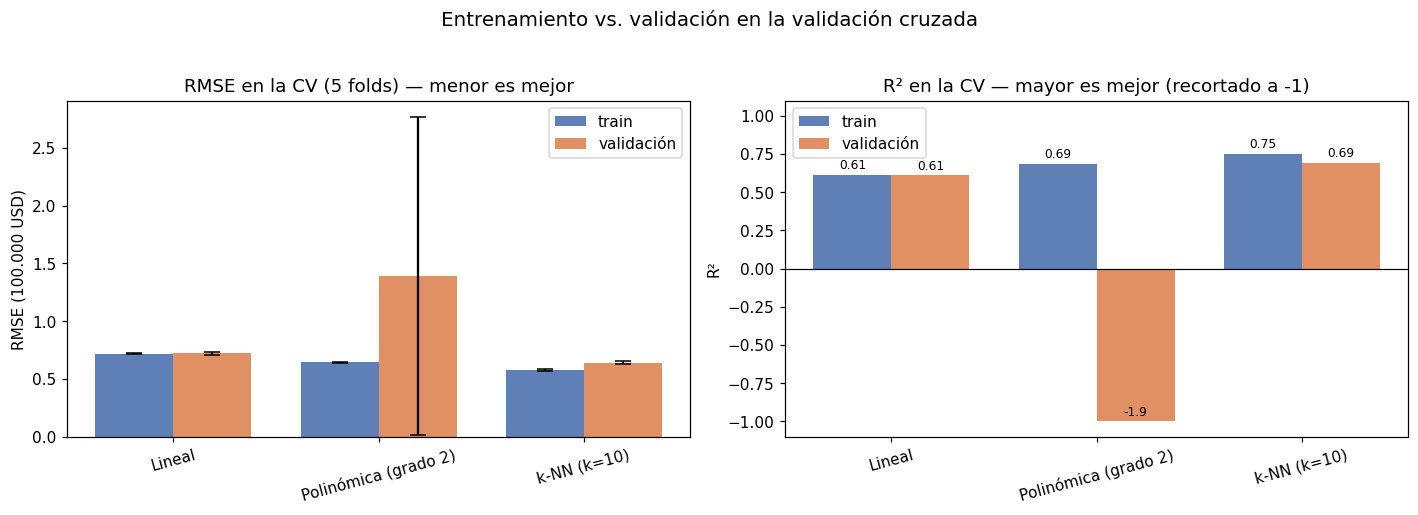

In [112]:
x = np.arange(len(cv_summary))
w = 0.38
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ---- RMSE: entrenamiento vs. validación ----
axes[0].bar(x - w / 2, cv_summary["RMSE train (media)"], w, label="train",
            yerr=cv_summary["RMSE train (std)"], capsize=5, color="#4C72B0", alpha=0.9)
axes[0].bar(x + w / 2, cv_summary["RMSE val (media)"], w, label="validación",
            yerr=cv_summary["RMSE val (std)"], capsize=5, color="#DD8452", alpha=0.9)
axes[0].set_title(f"RMSE en la CV ({N_SPLITS} folds) — menor es mejor")
axes[0].set_ylabel("RMSE (100.000 USD)")
if cv_summary[["RMSE train (media)", "RMSE val (media)"]].to_numpy().max() > 50:
    axes[0].set_yscale("log")
    axes[0].set_ylabel("RMSE — escala log")

# ---- R²: entrenamiento vs. validación (recortado a -1 para poder verlo) ----
r2_tr = cv_summary["R2 train (media)"].clip(lower=-1)
r2_va = cv_summary["R2 val (media)"].clip(lower=-1)
axes[1].bar(x - w / 2, r2_tr, w, label="train", color="#4C72B0", alpha=0.9)
axes[1].bar(x + w / 2, r2_va, w, label="validación", color="#DD8452", alpha=0.9)
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_ylim(-1.1, 1.1)
axes[1].set_title("R² en la CV — mayor es mejor (recortado a -1)")
axes[1].set_ylabel("R²")
for i in range(len(cv_summary)):
    axes[1].text(i - w / 2, r2_tr.iloc[i] + 0.04,
                 f"{cv_summary['R2 train (media)'].iloc[i]:.2g}", ha="center", fontsize=8)
    axes[1].text(i + w / 2, r2_va.iloc[i] + 0.04,
                 f"{cv_summary['R2 val (media)'].iloc[i]:.2g}", ha="center", fontsize=8)

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(cv_summary.index, rotation=15)
    ax.legend()
plt.suptitle("Entrenamiento vs. validación en la validación cruzada", y=1.03, fontsize=13)
plt.tight_layout()
plt.show()

## 6. Entrenamiento final y métricas sobre el conjunto de prueba

In [113]:
fitted = {}
test_rows = []

for name, model in models.items():
    model.fit(X_train, y_train)
    fitted[name] = model
    y_pred = model.predict(X_test)
    test_rows.append({
        "Modelo": name,
        "RMSE": root_mean_squared_error(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "R2": r2_score(y_test, y_pred),
    })

test_results = pd.DataFrame(test_rows).set_index("Modelo")
test_results.round(4)

,RMSE,MAE,R2
Modelo,,,
Lineal,0.7456,0.5332,0.5758
Polinómica (grado 2),0.6814,0.4670,0.6457
k-NN (k=10),0.6493,0.4403,0.6783


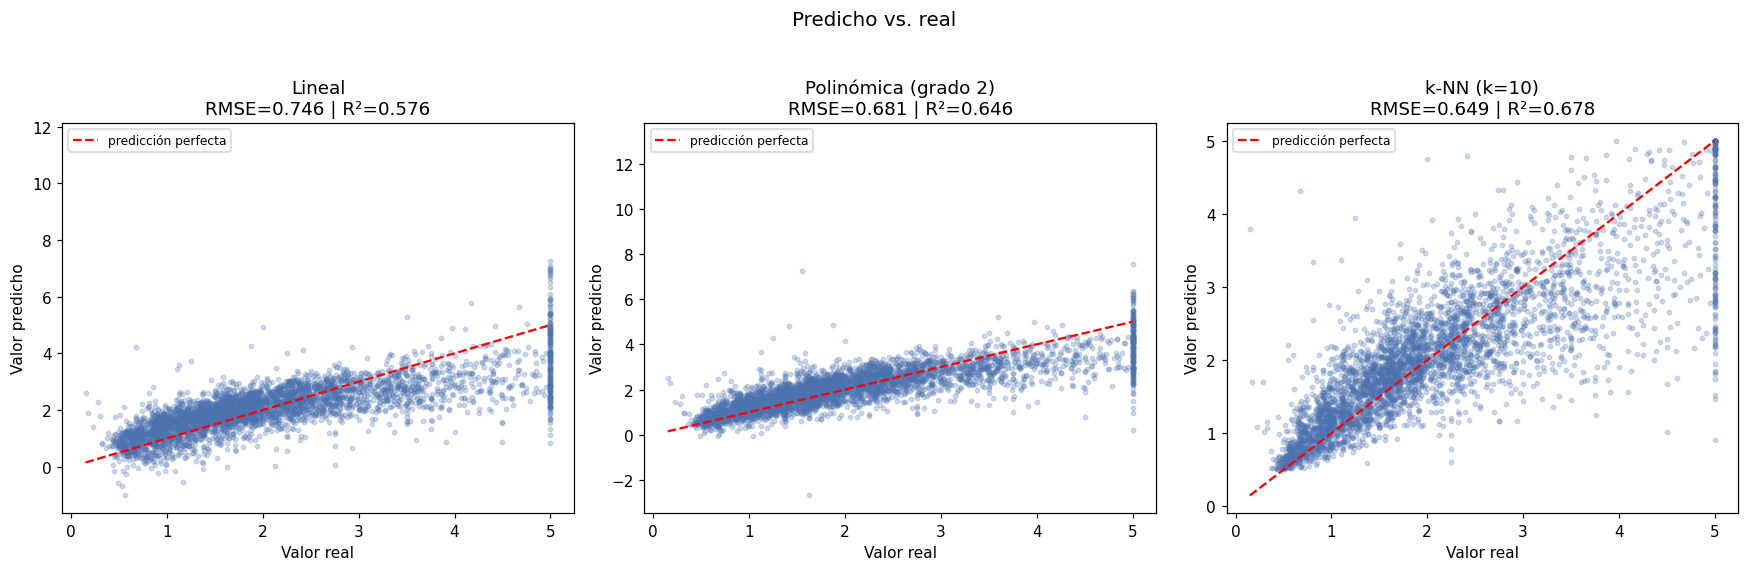

In [114]:
# Predicho vs. real (rendimiento sobre el conjunto de prueba)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
lims = [y_test.min(), y_test.max()]

for ax, (name, model) in zip(axes, fitted.items()):
    y_pred = model.predict(X_test)
    ax.scatter(y_test, y_pred, s=8, alpha=0.25, color="#4C72B0")
    ax.plot(lims, lims, "r--", lw=1.5, label="predicción perfecta")
    ax.set_xlabel("Valor real")
    ax.set_ylabel("Valor predicho")
    ax.set_title(f"{name}\nRMSE={test_results.loc[name, 'RMSE']:.3f} | R²={test_results.loc[name, 'R2']:.3f}")
    ax.legend(loc="upper left", fontsize=8)

plt.suptitle("Predicho vs. real", y=1.03, fontsize=13)
plt.tight_layout()
plt.show()

## 7. La "función" ajustada (line plot)

Una función de regresión sobre 8 variables no se puede dibujar. Para visualizarla, se reentrena cada modelo usando **una sola característica** (`VIZ_FEATURE = MedInc`, la más correlacionada con el precio) y se traza la curva predicha sobre todo su rango. Los puntos son una submuestra del conjunto de prueba.

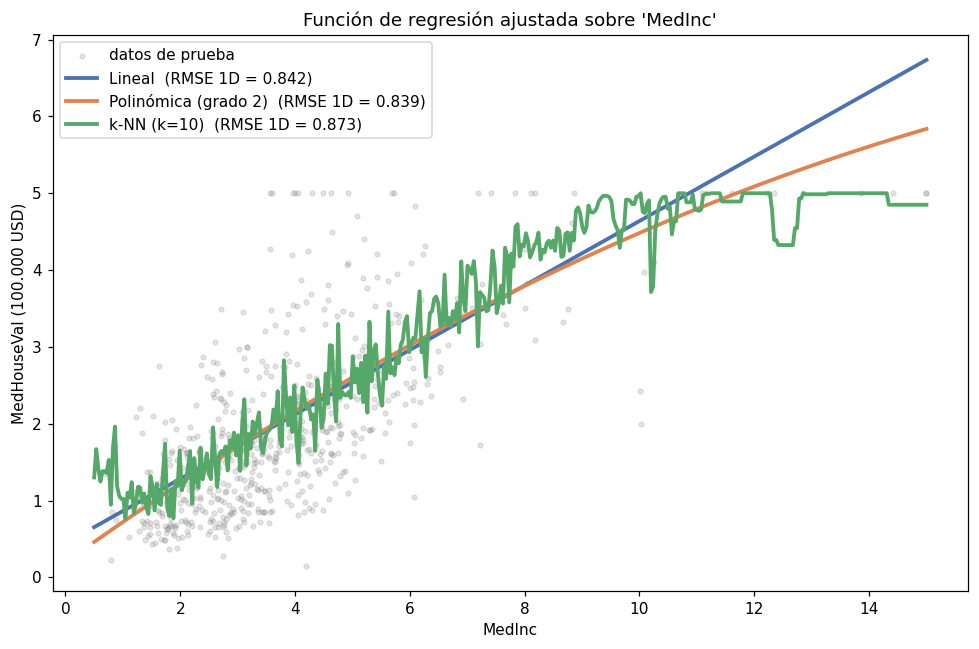

In [115]:
VIZ_FEATURE = "MedInc"  # característica usada para el line plot

x_tr = X_train[[VIZ_FEATURE]]
x_te = X_test[[VIZ_FEATURE]]

models_1d = {
    "Lineal": Pipeline([
        ("scaler", StandardScaler()),
        ("reg", LinearRegression()),
    ]),
    f"Polinómica (grado {POLY_DEGREE})": Pipeline([
        ("poly", PolynomialFeatures(degree=POLY_DEGREE, include_bias=False)),
        ("scaler", StandardScaler()),
        ("reg", LinearRegression()),
    ]),
    f"k-NN (k={N_NEIGHBORS})": Pipeline([
        ("scaler", StandardScaler()),
        ("reg", KNeighborsRegressor(n_neighbors=N_NEIGHBORS)),
    ]),
}

# rejilla ordenada sobre el rango de la característica
x_grid = np.linspace(x_tr[VIZ_FEATURE].min(), x_tr[VIZ_FEATURE].max(), 400).reshape(-1, 1)
x_grid_df = pd.DataFrame(x_grid, columns=[VIZ_FEATURE])

# submuestra de test para no saturar el gráfico
rng = np.random.default_rng(RANDOM_STATE)
idx = rng.choice(len(x_te), size=min(600, len(x_te)), replace=False)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(x_te.to_numpy()[idx], y_test.to_numpy()[idx], s=10, alpha=0.2,
           color="gray", label="datos de prueba")

line_colors = {"Lineal": "#4C72B0", f"Polinómica (grado {POLY_DEGREE})": "#DD8452", f"k-NN (k={N_NEIGHBORS})": "#55A868"}
for name, model in models_1d.items():
    model.fit(x_tr, y_train)
    y_line = model.predict(x_grid_df)
    rmse_1d = root_mean_squared_error(y_test, model.predict(x_te))
    ax.plot(x_grid, y_line, lw=2.5, color=line_colors[name],
            label=f"{name}  (RMSE 1D = {rmse_1d:.3f})")

ax.set_xlabel(VIZ_FEATURE)
ax.set_ylabel("MedHouseVal (100.000 USD)")
ax.set_title(f"Función de regresión ajustada sobre '{VIZ_FEATURE}'")
ax.legend()
plt.tight_layout()
plt.show()